<a href="https://colab.research.google.com/github/M4rcuSilv4/LAED/blob/main/Lista03_AV2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Operações básicas de pilha encadeada. Considere a pilha encadeada ilustrada a seguir.

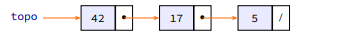

**a) Mostre, desenhando os nós e ponteiros, o estado da pilha após executar Push(topo,
99) e depois Push(topo, 3).**

topo -> [ 3 ] -> [ 99 ] -> [ 42 ] -> [ 17 ] -> [ 5 | / ]

**b) A partir do estado obtido em (a), mostre o estado após dois Pop. Qual valor foi
removido em cada chamada?**

topo -> [ 42 ] -> [ 17 ] -> [ 5 | / ]

No primeiro Pop() remove o nó com valor 3 e no segundo Pop() remove o nó com valor 99.

**c) Por que o Pop deve guardar o nó removido em uma variável auxiliar antes de avançar o
ponteiro topo? O que aconteceria se o nó fosse liberado da memória imediatamente,
antes de atualizar topo?**

Se o ponteiro topo for atualizado para topo->proximo antes de salvar a referência do nó atual, perde-se o endereço de memória do nó removido, gerando vazamento de memória (memory leak). Se desalocarmos a memória do nó antes de avançar topo (free(topo)), o ponteiro topo passará a apontar para uma região de memória inválida/desalocada (dangling pointer). Ao tentar acessar topo->proximo, o programa causará um erro de acesso inválido.

# 2. Fila encadeada com ponteiros inicio e fim. Considere a fila encadeada abaixo, onde a remoção ocorre em inicio e a inserção em fim.
____
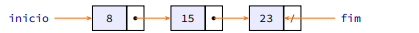

**a) Insira os valores 7 e 11 na fila e desenhe o estado resultante.**

inicio -> [ 8 ] -> [ 15 ] -> [ 23 ] -> [ 7 ] -> [ 11 | / ] <- fim

**b) Realize dois Dequeue e desenhe o estado resultante.**

inicio -> [ 23 ] -> [ 7 ] -> [ 11 | / ] <- fim

**c) Descreva com precisão o que deve ocorrer com os ponteiros inicio e fim quando a
última remoção esvazia a fila. O que acontece se apenas inicio for zerado, mas fim
não?**

Ambos os ponteiros (inicio e fim) devem ser atualizados para NULL (ou NULO). Se apenas inicio for zerado o ponteiro fim se tornará um ponteiro fantasma (dangling pointer), continuando a apontar para a memória do nó removido/desalocado. Em inserções futuras (Enqueue), o código tentará fazer fim->proximo = novo_no, o que provocará um erro de violação de acesso.

# 3. Inversão de fila com pilha auxiliar. Dada uma fila encadeada com 𝑛 elementos, projete um algoritmo que inverta a ordem dos elementos usando apenas uma pilha encadeada auxiliar (sem vetores ou outras estruturas).
___

**a) Escreva o pseudocódigo e trace sua execução para a fila 《1, 2, 3, 4》, onde 1 está em
inicio.**

In [ ]:
class No:
    def __init__(self, dado):
        self.dado = dado
        self.proximo = None


class PilhaEncadeada:
    def __init__(self):
        self.topo = None

    def esta_vazia(self):
        return self.topo is None

    def push(self, valor):
        novo_no = No(valor)
        novo_no.proximo = self.topo
        self.topo = novo_no

    def pop(self):
        if self.esta_vazia():
            return None
        retirado = self.topo
        self.topo = self.topo.proximo
        return retirado.dado


class FilaEncadeada:
    def __init__(self):
        self.inicio = None
        self.fim = None

    def esta_vazia(self):
        return self.inicio is None

    def enqueue(self, valor):
        novo_no = No(valor)
        if self.esta_vazia():
            self.inicio = novo_no
            self.fim = novo_no
        else:
            self.fim.proximo = novo_no
            self.fim = novo_no

    def dequeue(self):
        if self.esta_vazia():
            return None
        retirado = self.inicio
        self.inicio = self.inicio.proximo
        if self.inicio is None:
            self.fim = None
        return retirado.dado


def inverter_fila(fila):
    pilha = PilhaEncadeada()

    while not fila.esta_vazia():
        elemento = fila.dequeue()
        pilha.push(elemento)

    while not pilha.esta_vazia():
        elemento = pilha.pop()
        fila.enqueue(elemento)


fila_principal = FilaEncadeada()
fila_principal.enqueue(1)
fila_principal.enqueue(2)
fila_principal.enqueue(3)
fila_principal.enqueue(4)

print("Fila Original:")
no_atual = fila_principal.inicio
valores = []
while no_atual:
    valores.append(str(no_atual.dado))
    no_atual = no_atual.proximo
print("inicio -> " + " -> ".join(valores) + " <- fim")

inverter_fila(fila_principal)

print("\nFila Invertida:")
no_atual = fila_principal.inicio
valores = []
while no_atual:
    valores.append(str(no_atual.dado))
    no_atual = no_atual.proximo
print("inicio -> " + " -> ".join(valores) + " <- fim")

Fila Original:
inicio -> 1 -> 2 -> 3 -> 4 <- fim

Fila Invertida:
inicio -> 4 -> 3 -> 2 -> 1 <- fim


**b) Analise a complexidade de tempo e espaço.**

O algoritmo possui tempo de execução O(N), pois percorre todos os N elementos da fila para transferi-los à pilha e depois percorre novamente todos os N elementos para devolvê-los à fila, de modo independente, realizando operações de inserção e remoção em tempo constante O(1).

**c) É possível inverter a fila in-place, sem nenhuma estrutura auxiliar, usando apenas
manipulação de ponteiros? Justifique.**

Sim, como a fila encadeada é composta internamente por nós com ponteiros de encadeamento simples (cada nó possui o endereço do próximo), inverter a fila equivale ao problema de inverter uma lista encadeada simples. Basta iterar pelos nós invertendo o sentido das conexões (atual->proximo = anterior) e ao final inverter os ponteiros de controle inicio e fim. Esta abordagem consome O(N) de tempo e O(1) de espaço auxiliar.

# 4. Pilha com mínimo em 𝑂(1). Projete uma pilha encadeada que, além das operações usuais Push e Pop, suporte a operação Min, que retorna o menor elemento presente na pilha em tempo 𝑂(1) — sem percorrer a lista.
____

**a) Descreva a estrutura de dados (quais campos cada nó deve conter).**

Cada nó da pilha encadeada deve conter três campos:

• ​dado: o valor do elemento armazenado;

• ​min_atual: o menor valor presente na pilha até aquele nó (mínimo histórico daquela posição para baixo);

​• proximo: ponteiro/referência para o nó abaixo na pilha.

**b) Escreva os pseudocódigos de Push, Pop e Min, todos em 𝑂(1).**

In [ ]:
class NoMin:
    def __init__(self, dado, min_atual):
        self.dado = dado
        self.min_atual = min_atual
        self.proximo = None


class PilhaMin:
    def __init__(self):
        self.topo = None

    def push(self, valor):
        if self.topo is None:
            minimo_novo = valor
        else:
            minimo_novo = min(valor, self.topo.min_atual)

        novo_no = NoMin(valor, minimo_novo)
        novo_no.proximo = self.topo
        self.topo = novo_no

    def pop(self):
        if self.topo is None:
            return None
        retirado = self.topo
        self.topo = self.topo.proximo
        return retirado.dado

    def min_val(self):
        if self.topo is None:
            return None
        return self.topo.min_atual

**c) Trace a execução para a sequência de operações:
Push(5), Push(3), Push(7), Push(1), Pop, Min.
Mostre o estado da pilha e o valor mínimo registrado em cada passo.**

Sequência de operações:

Push(5), Push(3), Push(7), Push(1), Pop, Min.

_

​Push(5):

​Pilha: [5 (min: 5)]

​Mínimo registrado: 5

_

​Push(3):
​Pilha: [3 (min: 3)] -> [5 (min: 5)]

​Mínimo registrado: 3

_

​Push(7):

​Pilha: [7 (min: 3)] -> [3 (min: 3)] -> [5 (min: 5)]

​Mínimo registrado: 3

_

​Push(1):

​Pilha: [1 (min: 1)] -> [7 (min: 3)] -> [3 (min: 3)] -> [5 (min: 5)]

​Mínimo registrado: 1

_

​Pop():
​Remove o nó com valor 1.

​Pilha restante: [7 (min: 3)] -> [3 (min: 3)] -> [5 (min: 5)]

_

​Min():

​Acessa topo.min_atual.

​Valor retornado: 3

**c) Qual é o custo extra de memória em relação a uma pilha encadeada comum? Expresse
em 𝑂(·).**

Custo de execução: O(N), cada um dos N nós armazena um valor inteiro a mais (min_atual). O número de ponteiros e o total de nós continuam N, mantendo o uso adicional proporcional de forma linear.

# 5. Balanceamento de delimitadores. Uma expressão pode conter três tipos de delimitadores: parênteses (), colchetes [] e chaves {}. Um algoritmo baseado em pilha verifica se os delimitadores estão corretamente aninhados.

____

**a) Escreva o algoritmo usando uma pilha encadeada. Para cada caractere da entrada: se
for abridor, empilhe; se for fechador, desempilhe e verifique o par.**

In [ ]:
class No:
    def __init__(self, dado):
        self.dado = dado
        self.proximo = None


class PilhaEncadeada:
    def __init__(self):
        self.topo = None

    def esta_vazia(self):
        return self.topo is None

    def push(self, valor):
        novo_no = No(valor)
        novo_no.proximo = self.topo
        self.topo = novo_no

    def pop(self):
        if self.esta_vazia():
            return None
        retirado = self.topo
        self.topo = self.topo.proximo
        return retirado.dado


def verificar_delimitadores(expressao):
    pilha_aux = PilhaEncadeada()
    correspondencias = {')': '(', ']': '[', '}': '{'}

    for indice, caractere in enumerate(expressao):
        if caractere in "([{":
            pilha_aux.push(caractere)
        elif caractere in ")]}":
            if pilha_aux.esta_vazia():
                return False, f"Erro na posição {indice}: fechador '{caractere}' sem abridor correspondente"

            valor_topo = pilha_aux.pop()
            if valor_topo != correspondencias[caractere]:
                return False, f"Erro na posição {indice}: esperava fechador para '{valor_topo}', mas encontrou '{caractere}'"

    if not pilha_aux.esta_vazia():
        return False, f"Erro: abridor '{pilha_aux.topo.dado}' não foi fechado até o fim da expressão"

    return True, "Expressão válida"

**b) Analise a complexidade de tempo e espaço em função do comprimento N  da expressão.**

Tempo de Execução: O(n). O algoritmo realiza uma única varredura sobre a expressão de tamanho n. Cada caractere executa uma operação de push ou pop na pilha encadeada, levando tempo constante O(1) por passo.

​Espaço Auxiliar: O(n). No pior caso, por exemplo, uma sequência de n abridores ((((..., a pilha armazena até n caracteres simultaneamente.

**c) Aplique o algoritmo às cadeias abaixo e indique se são válidas. Para as inválidas, identi-
fique a posição e o tipo do erro.**
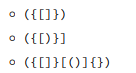

In [ ]:
class No:
    def __init__(self, dado):
        self.dado = dado
        self.proximo = None


class PilhaEncadeada:
    def __init__(self):
        self.topo = None

    def esta_vazia(self):
        return self.topo is None

    def push(self, valor):
        novo_no = No(valor)
        novo_no.proximo = self.topo
        self.topo = novo_no

    def pop(self):
        if self.esta_vazia():
            return None
        retirado = self.topo
        self.topo = self.topo.proximo
        return retirado.dado


def verificar_delimitadores(expressao):
    pilha_aux = PilhaEncadeada()
    correspondencias = {')': '(', ']': '[', '}': '{'}

    for indice, caractere in enumerate(expressao):
        if caractere in "([{":
            pilha_aux.push(caractere)
        elif caractere in ")]}":
            if pilha_aux.esta_vazia():
                return False, f"Erro na posição {indice}: Fechador '{caractere}' sem abridor correspondente"

            valor_topo = pilha_aux.pop()
            if valor_topo != correspondencias[caractere]:
                return False, f"Erro na posição {indice}: Esperava fechador para '{valor_topo}', mas encontrou '{caractere}'"

    if not pilha_aux.esta_vazia():
        return False, f"Erro no final: Abridor '{pilha_aux.topo.dado}' não foi fechado"

    return True, "Válida"


sequencias = [
    "({[]})",
    "({[]}]",
    "({[]}){[()]}{}"
]

for sequencia in sequencias:
    eh_valida, mensagem = verificar_delimitadores(sequencia)
    print(f"Cadeia: {sequencia}")
    print(f"Resultado: {'VÁLIDA' if eh_valida else 'INVÁLIDA'}")
    print(f"Detalhe: {mensagem}\n")

Cadeia: ({[]})
Resultado: VÁLIDA
Detalhe: Válida

Cadeia: ({[]}]
Resultado: INVÁLIDA
Detalhe: Erro na posição 5: Esperava fechador para '(', mas encontrou ']'

Cadeia: ({[]}){[()]}{}
Resultado: VÁLIDA
Detalhe: Válida



# 6. Fila com duas pilhas encadeadas. É possível simular uma fila usando duas pilhas, chamadas 𝑃1 (entrada) e 𝑃2 (saída). A inserção sempre empilha em 𝑃1. A remoção retira o topo de 𝑃2; se 𝑃2 estiver vazia, todos os elementos de 𝑃1 são transferidos para 𝑃2 antes da remoção
____

**a) Escreva os pseudocódigos de Enqueue e Dequeue usando essa ideia.**

In [ ]:
class FilaDuasPilhas:
    def __init__(self):
        self.p1 = PilhaEncadeada()
        self.p2 = PilhaEncadeada()

    def enqueue(self, valor):
        self.p1.push(valor)

    def dequeue(self):
        if self.p2.esta_vazia():
            while not self.p1.esta_vazia():
                self.p2.push(self.p1.pop())

        if self.p2.esta_vazia():
            return None

        return self.p2.pop()

**b) Mostre que o custo amortizado de Dequeue é O(1), mesmo que uma chamada individual possa custar O(N).**

...

**c)  A transferência de 𝑃1 para 𝑃2 preserva a propriedade FIFO? Justifique com um exemplo.**

A propriedade FIFO (First-In, First-Out) é preservada devido à dupla inversão da ordem LIFO (Last-In, First-Out) das pilhas:
​Quando um elemento entra em P_1, ele fica empilhado na ordem de chegada.
​Ao transferir os elementos de P_1 para P_2, a ordem do topo ao fundo de P_1 é invertida em P_2. O primeiro elemento que entrou em P_1 (o mais antigo) passa a ser o elemento no topo de P_2.
​As remoções efetuadas em P_2 retiram sempre o elemento mais antigo da fila primeiro.

# 7. Radix Sort e estabilidade. O Radix Sort processa dígitos do menos significativo para o mais significativo e depende de que a distribuição nas filas seja estável.
___

**a) Explique, com um contra-exemplo concreto, o que ocorreria se as filas fossem substitu-
ídas por pilhas no passo de coleta.**

Considere os números 12 e 22. Ambos possuem o mesmo dígito na casa das unidades (dígito 2).

​Ordenando pelas Unidades:

​- 12 entra primeiro no balde 2, e 22 entra em seguida.

​- Com Filas (FIFO): Na coleta, sai 12 e depois 22 (preserva a ordem relativa).

​-Com Pilhas (LIFO): Na coleta do balde 2, o topo é o 22. Portanto, saem 22 e depois 12.

_

Se aplicarmos essa lógica em números de mais dígitos, o comportamento LIFO reverte o progresso feito pelos dígitos menos significativos, tornando o resultado final incorreto (não ordenado).

**b) Trace a execução do Radix Sort para a sequência 481, 329, 143, 612, 937, 480, 256,
mostrando o conteúdo das 10 filas e a sequência coletada após cada passagem.**

Sequência Inicial: [481, 329, 143, 612, 937, 480, 256]


- ​1ª Passagem (Unidades - Dígito menos significativo):

​Fila 0: 480

​Fila 1: 481

​Fila 2: 612

​Fila 3: 143

​Fila 4: (vazia)

​Fila 5: (vazia)

​Fila 6: 256

​Fila 7: 937

​Fila 8: (vazia)

​Fila 9: 329

Sequência coletada (0 a 9): [480, 481, 612, 143, 256, 937, 329]

_


​2ª Passagem (Dezenas):

​Fila 0: (vazia)

​Fila 1: 612

​Fila 2: 329

​Fila 3: 937

​Fila 4: 143

​Fila 5: 256

​Fila 6: (vazia)

​Fila 7: (vazia)

​Fila 8: 480, 481

​Fila 9: (vazia)

​Sequência coletada (0 a 9): [612, 329, 937, 143, 256, 480, 481]

_


​3ª Passagem (Centenas - Dígito mais significativo):

​Fila 0: (vazia)

​Fila 1: 143

​Fila 2: 256

​Fila 3: 329

​Fila 4: 480, 481

​Fila 5: (vazia)

​Fila 6: 612

​Fila 7: (vazia)

​Fila 8: (vazia)

​Fila 9: 937

_

​
Sequência coletada final (0 a 9): [143, 256, 329, 480, 481, 612, 937]

**c) Qual é a complexidade do Radix Sort quando aplicado a 𝑛 strings de comprimento
fixo  sobre um alfabeto de tamanho 𝜎 ? Compare com Merge Sort para o mesmo
problema.**

Na ordenacao de strings de comprimento fixo L sobre um alfabeto de tamanho SIGMA, a complexidade de tempo do Radix Sort e O(L * (N + SIGMA)). Como o comprimento L e o tamanho do alfabeto SIGMA sao valores constantes, o tempo de execucao do Radix Sort torna-se linear O(N). Em comparacao, o Merge Sort opera realizando comparacoes diretas entre as palavras, o que leva tempo de execucao O(L * N * log N) no pior caso. A principal vantagem do Radix Sort e processar os caracteres por posicao sem realizar comparacoes diretas entre os elementos, superando o limite teorico de O(N log N) e sendo mais eficiente que o Merge Sort para esse cenário.